In [1]:
import pandas as pd
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# Задача о разорении

In [92]:
def walk(n, p):
    S = np.zeros(n)
    s = 0
    for i in range(n):
        a = sps.bernoulli.rvs(p)
        if a == 0: s+=1
        else: s-=1
        S[i] = s
    return S

In [93]:
A = 10
B = 15
n = 2000
tau = np.zeros(n)
prob = np.zeros(n)

for i in range(n):
    j = 0
    S = 0
    while tau[i] == 0:
        if S == B:
            tau[i] = j
            prob[i] = 1
        if S == -A:
            tau[i] = j
            prob[i] = 0
        else:
            j+=1
            a = sps.bernoulli.rvs(1/2)
            if a == 0: S+=1
            else: S-=1
        
print(f'Эмпиричиеская вероятность победы В: {np.mean(prob)}')
print(f'Теоритическая вероятность победы В: {A/(B+A)}')

print(f'Эмпиричиеская время окончания игры: {np.mean(tau)}')
print(f'Теоритическая вероятность победы В: {A*B}')

Эмпиричиеская вероятность победы В: 0.414
Теоритическая вероятность победы В: 0.4
Эмпиричиеская время окончания игры: 142.794
Теоритическая вероятность победы В: 150


# Вальдовский подход


## Вспомогательные функции

In [ ]:
def prob_wald(A, B):

    denom = np.exp( A + B ) - 1

    alpha = ( np.exp( B ) - 1 ) / denom
    beta = ( np.exp( A ) - 1 ) / denom
    
    return alpha, beta

In [ ]:
def border_wald(alpha, beta):

    A = np.log((1 - beta) / alpha)
    B = np.log((1 - alpha) / beta)
    
    return A, B

## Пример работы 1

\begin{align*}

    X_i &\sim Bern(\theta) \\
    H_0 &\colon \theta = \theta_0, \\
    H_1 &\colon \theta = \theta_1.

    
\end{align*}
 


In [ ]:
theta0 = -1
theta1 = 1
theta_set = [1/3, 2/3, 1/2]

alpha = 0.05
beta = 0.05

In [ ]:
A , B  = border_wald(alpha, beta)

print(A, B)

2.9444388737831853 2.9444388737831853
2.9444389791664403 2.9444389791664403


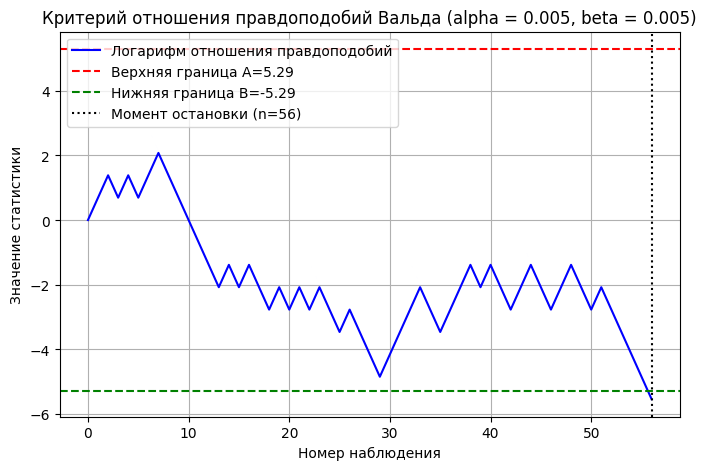

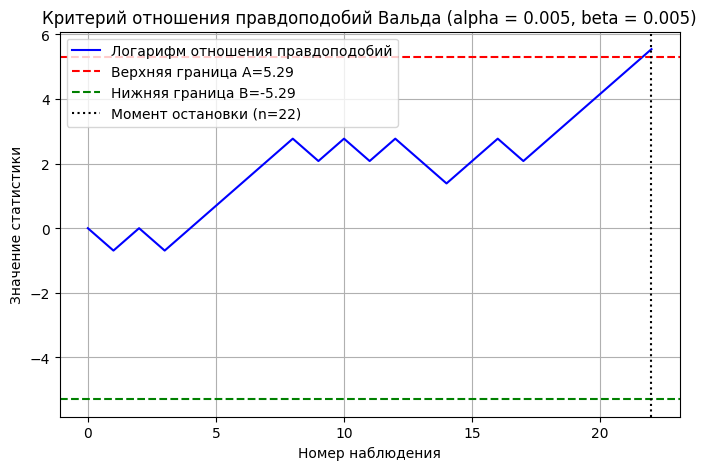

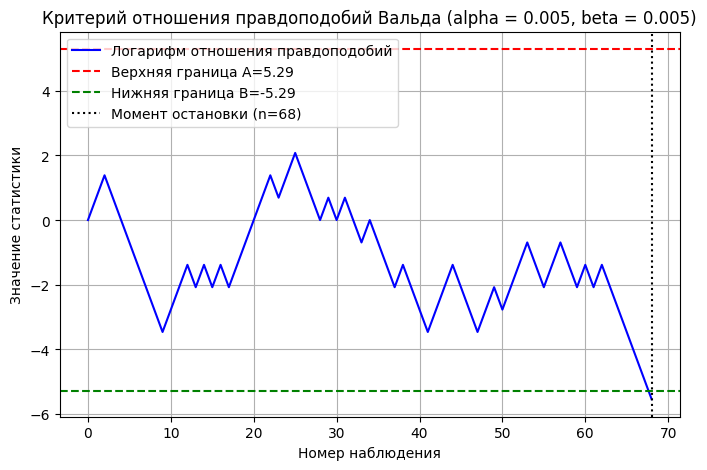

In [ ]:

for theta in theta_set:
    N = 1000
    S = np.zeros(N+1)
    n = 0
    stop_idx = N

    while n < N and (S[n] <= A and S[n] >= B):
        X = sps.bernoulli.rvs(p=theta)
        S[n+1] = S[n] - (1-X)*np.log((1-theta0)/(1-theta1)) - X*np.log(theta0/theta1)
        if S[n+1] > A or S[n+1] < B:
            stop_idx = n+1
        n += 1

    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(stop_idx+1), S[:stop_idx+1], 'b-', label='Логарифм отношения правдоподобий')
    plt.axhline(y=A, color='r', linestyle='--', label=f'Верхняя граница A={A:.2f}')
    plt.axhline(y=B, color='g', linestyle='--', label=f'Нижняя граница B={B:.2f}')
    plt.axvline(x=stop_idx, color='k', linestyle=':', label=f'Момент остановки (n={stop_idx})')
    plt.xlabel('Номер наблюдения')
    plt.ylabel('Значение статистики')
    plt.title(f'Критерий отношения правдоподобий Вальда (alpha = {alpha}, beta = {beta})')
    plt.legend()
    plt.grid(True)
    plt.show()



## Пример работы 2

\begin{align*}

    X_i &\sim N(\theta , \sigma) \\
    H_0 &\colon \theta = \theta_0, \\
    H_1 &\colon \theta = \theta_1.

    
\end{align*}

In [ ]:
theta_set = [1/3, 2/3, 1/2]
theta0 = 1/3
theta1 = 2/3
sigma = 1

alpha = 0.005
beta = 0.005

A , B  = border_wald(alpha, beta)

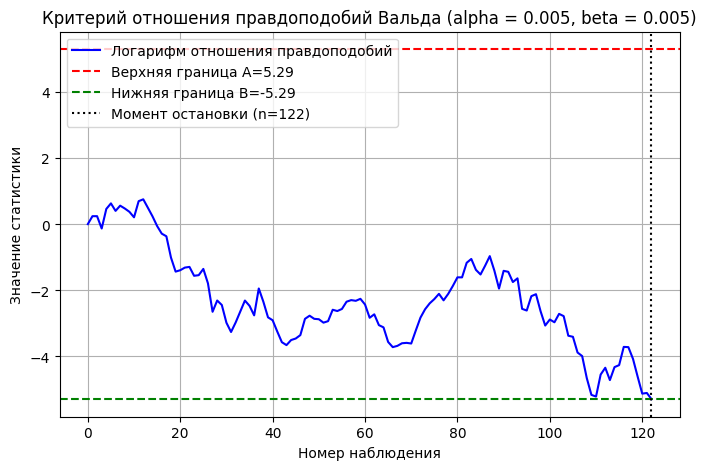

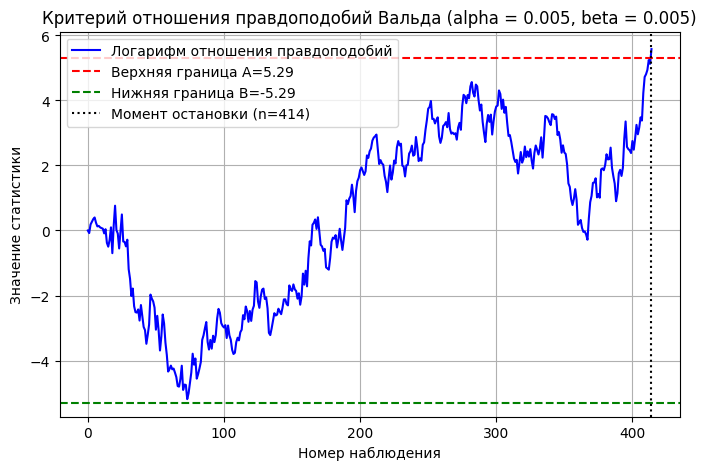

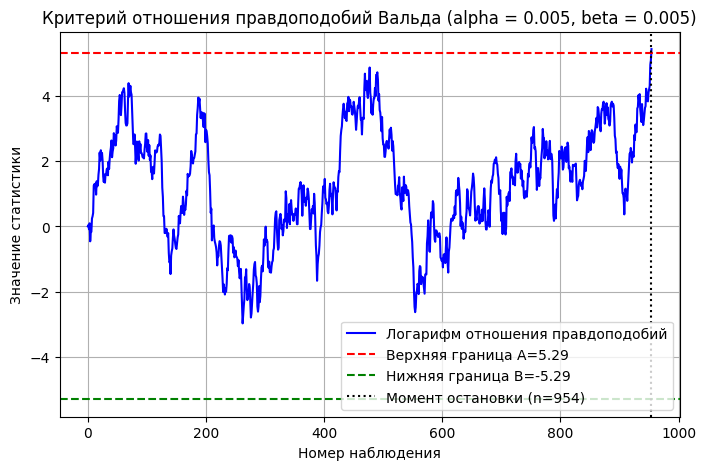

In [ ]:
for theta in theta_set:
    N = 1000
    S = np.zeros(N+1)
    n = 0
    stop_idx = N

    while n < N and (S[n] <= A and S[n] >= B):
        X = sps.norm.rvs(loc=theta, scale=sigma)
        S[n+1] = S[n] - (theta1-theta0)*(theta1+theta0-2*X)/(2*(sigma**2))
        if S[n+1] > A or S[n+1] < B:
            stop_idx = n+1
        n += 1

    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(stop_idx+1), S[:stop_idx+1], 'b-', label='Логарифм отношения правдоподобий')
    plt.axhline(y=A, color='r', linestyle='--', label=f'Верхняя граница A={A:.2f}')
    plt.axhline(y=B, color='g', linestyle='--', label=f'Нижняя граница B={B:.2f}')
    plt.axvline(x=stop_idx, color='k', linestyle=':', label=f'Момент остановки (n={stop_idx})')
    plt.xlabel('Номер наблюдения')
    plt.ylabel('Значение статистики')
    plt.title(f'Критерий отношения правдоподобий Вальда (alpha = {alpha}, beta = {beta})')
    plt.legend()
    plt.grid(True)
    plt.show()

## Пример работы 3

\begin{align*}

    X_i &\sim Exp (\theta) \\
    H_0 &\colon \theta = \theta_0, \\
    H_1 &\colon \theta = \theta_1.

    
\end{align*}

In [ ]:
theta_set = [1/3, 2/3, 1/2]
theta0 = 1/3
theta1 = 2/3

alpha = 0.005
beta = 0.005

A , B  = border_wald(alpha, beta)

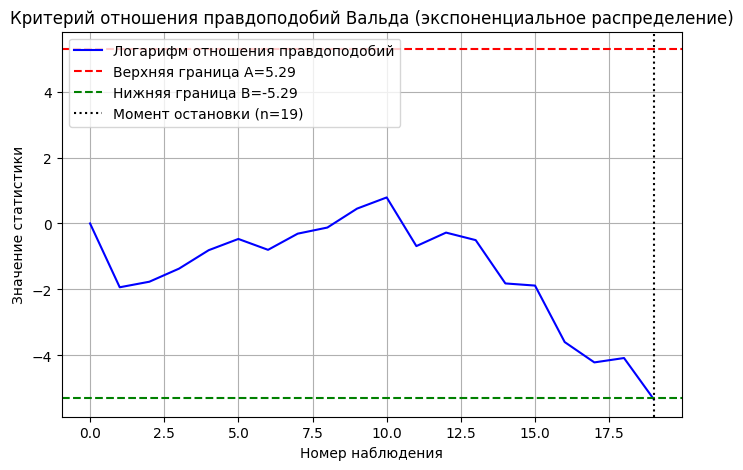

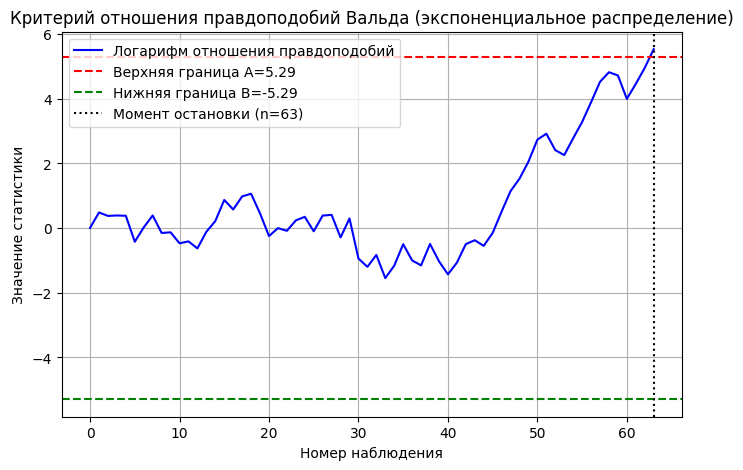

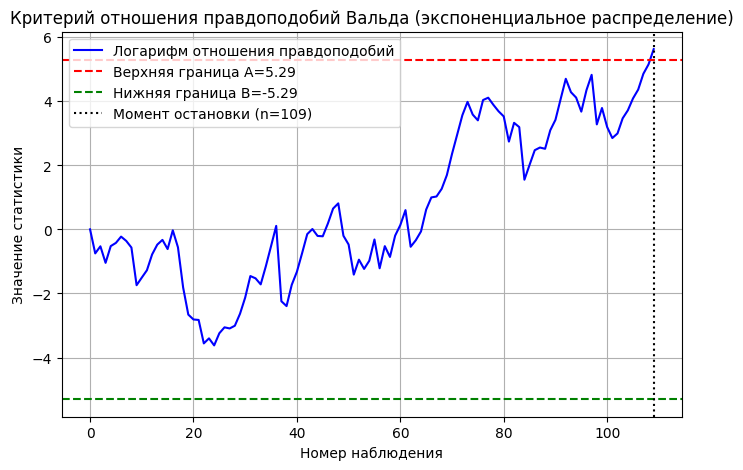

In [ ]:
for theta in theta_set:
    N = 1000
    S = np.zeros(N+1)
    n = 0
    stop_idx = N

    while n < N and (S[n] <= A and S[n] >= B):
        X = sps.expon.rvs(scale=1/theta)
        S[n+1] = S[n] + np.log(theta1/theta0) + (theta0 - theta1)*X
        if S[n+1] > A or S[n+1] < B:
            stop_idx = n+1
        n += 1

    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(stop_idx+1), S[:stop_idx+1], 'b-', label='Логарифм отношения правдоподобий')
    plt.axhline(y=A, color='r', linestyle='--', label=f'Верхняя граница A={A:.2f}')
    plt.axhline(y=B, color='g', linestyle='--', label=f'Нижняя граница B={B:.2f}')
    plt.axvline(x=stop_idx, color='k', linestyle=':', label=f'Момент остановки (n={stop_idx})')
    plt.xlabel('Номер наблюдения')
    plt.ylabel('Значение статистики')
    plt.title('Критерий отношения правдоподобий Вальда (экспоненциальное распределение)')
    plt.legend()
    plt.grid(True)
    plt.show()

## Среднее время остановки

Среднее время остановки за 1000 итераций: 55.41
Приближенное среднее время ожидания при H0: 80.55840859029963
Ожидаемое время при H0: 52.39
Ожидаемое время при H1: 75.18


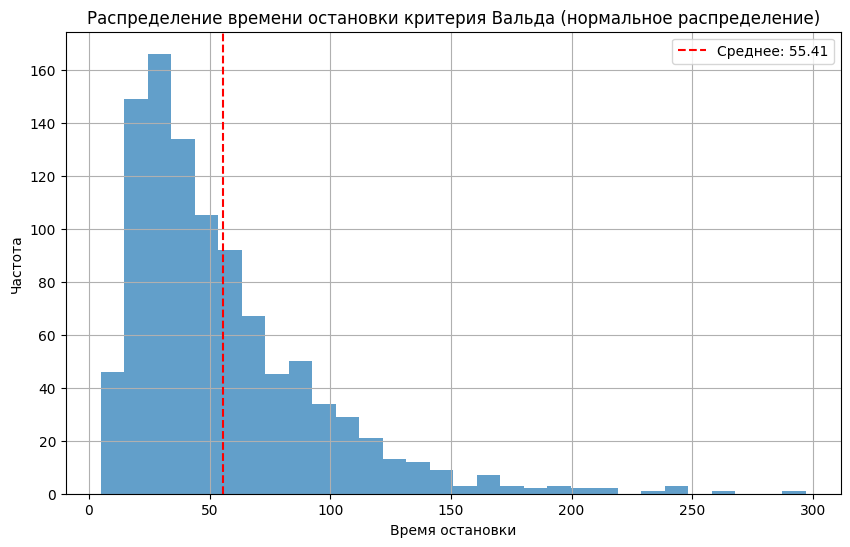

In [ ]:
theta = 1/3
theta0 = 1/3
theta1 = 2/3
sigma = 1
I = ((sigma**2 + (theta0 - theta1)**2)/(2*sigma**2) - 0.5) # расстояния Кульбака-Лейблера

alpha = 0.01
beta = 0.05
A = np.log((1-beta)/alpha)
B = np.log(beta/(1-alpha))

T = (A * (1 - (np.exp(A) - 1) / (np.exp(A-B) - 1) ) - B * ((np.exp(A) - 1)/(np.exp(A-B) - 1) ))/I
N = 1000
num = 1000
stopping_times = np.zeros(num)

for i in range(num):
    S = np.zeros(N+1)
    n = 0
    stop_idx = N
    
    while n < N and (S[n] <= A and S[n] >= B):
        X = sps.norm.rvs(loc=theta, scale=sigma)
        S[n+1] = S[n] - (theta1-theta0)*(theta1+theta0-2*X)/(2*(sigma**2))
        if S[n+1] > A or S[n+1] < B:
            stop_idx = n+1
        n += 1
    
    stopping_times[i] = stop_idx

average_stopping_time = np.mean(stopping_times)
print(f"Среднее время остановки за {num} итераций: {average_stopping_time:.2f}")
print(f"Приближенное среднее время ожидания при H0: {T}")

T_H0 = (alpha * A + (1 - alpha) * B) / (-I)
print(f"Ожидаемое время при H0: {T_H0:.2f}")


T_H1 = ((1 - beta) * A + beta * B) / I
print(f"Ожидаемое время при H1: {T_H1:.2f}")

plt.figure(figsize=(10, 6))
plt.hist(stopping_times, bins=30, alpha=0.7)
plt.axvline(average_stopping_time, color='r', linestyle='--', 
           label=f'Среднее: {average_stopping_time:.2f}')
plt.xlabel('Время остановки')
plt.ylabel('Частота')
plt.title('Распределение времени остановки критерия Вальда (нормальное распределение)')
plt.legend()
plt.grid(True)
plt.show()

## Эмпирические вероятности ошибок 1 и 2 рода

In [2]:
def calculate_errors(theta_set, theta0, theta1, sigma, alpha, beta, num_trials):
    A = np.log((1 - beta) / alpha)
    B = np.log(beta / (1 - alpha))

    type1_errors = 0
    type2_errors = 0

    for _ in range(num_trials):
        for true_theta in theta_set:
            N = 1000
            S = np.zeros(N + 1)
            n = 0
            stop_idx = N

            while n < N and (S[n] <= A and S[n] >= B):
                X = sps.norm.rvs(loc=true_theta, scale=sigma)
                S[n + 1] = S[n] - (theta1 - theta0) * (theta1 + theta0 - 2 * X) / (2 * (sigma ** 2))
                if S[n + 1] > A or S[n + 1] < B:
                    stop_idx = n + 1
                n += 1

            if true_theta == theta0:
                if S[stop_idx] >= A:
                    type1_errors += 1
            elif true_theta == theta1:
                if S[stop_idx] <= B:
                    type2_errors += 1
            #print(S[stop_idx])
            #print(A,B)

    emp_alpha = type1_errors / num_trials
    emp_beta = type2_errors / num_trials
    return emp_alpha, emp_beta


In [ ]:
theta_set = [1/3, 2/3]
theta0 = 1/3
theta1 = 2/3
sigma = 1
alpha = 0.005
beta = 0.1
num_trials = 1000

emp_alpha, emp_beta = calculate_errors(theta_set, theta0, theta1, sigma, alpha, beta, num_trials)
print(f"Эмпирические ошибки первого и второго рода: {emp_alpha, emp_beta}")